## Context 

E-Mart is a Chinese retailer that discovered the e-commerce as a way to sell to the entire world, rather than just to the population of their home city. The company has been growing without much worries, and now It wants to start using the data collected during its 4 years of e-commerce to keep growing and make more money.

Cycle 1 

The board of directors expects:

- A Dashboard with KPIs to track their growth.

- Robust Data Analysis, as well as recommendation of actions. What's the actionable based on your analysis?

- **An Analysis about the countries, a segmentation by sales, profit and more. They need insights to help increasing revenue.**

- Sales forecast for the next year, in order to enable strategic planning.

## Agenda


[0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1 Natural Segmentation](#1-Natural-Segmentation)<br>
&emsp;[1.1 Transactions per Country](#1.1-Transactions-per-Country)<br>
&emsp;[1.2 Sales and Profit per Country](#1.2-Sales-and-Profit-per-Country)<br>
&emsp;[1.3 Transactions by Country Analytical Base Table](#1.3-Transactions-by-Country-Analytical-Base-Table)<br>
&emsp;&emsp;[1.3.1. Analysis](#1.3.1.-Analysis)<br>
&emsp;&emsp;&emsp;[Categorial Variables](#Categorial-Variables)<br>
&emsp;&emsp;&emsp;&emsp;[City and State](#City-and-State)<br>
&emsp;&emsp;&emsp;[Numerical Variables](#Numerical-Variables)<br>

[2 Clustering Algorithm](#2-Clustering-Algorithm)<br>
&emsp;[2.1 Feature Engineering](#2.1-Feature-Engineering)<br>
&emsp;[2.2 Algorithm](#2.2-Algorithm)<br>
&emsp;[2.3 Analysis](#2.3-Analysis)<br>
&emsp;&emsp;&emsp;[2.3.1 Numerical Variables](#2.3.1-Numerical-Variables)<br>
&emsp;&emsp;&emsp;[2.3.2 Categorical Variables](#2.3.2-Categorical-Variables)<br>

[3 Classifying Clusters](#3-Classifying-Clusters)<br>
&emsp;[3.1 Random Forest](#3.1-Random-Forest)<br>

[4 Grouping Countries with Similar Transactions](#4-Grouping-Countries-with-Similar-Transactions)<br>

[5 Clustering Countries](#5-Clustering-Countries)<br>
&emsp;[5.1 Countries Analytial Base Table](#5.1-Countries-Analytial-Base-Table)<br>
&emsp;&emsp;[5.1.2 Feature Engineering](#5.1.2-Feature-Engineering)<br>
&emsp;&emsp;[5.1.3 Feature Selection](#5.1.3-Feature-Selection)<br>
&emsp;&emsp;[5.1.4 Modeling](#5.1.4-Modeling)<br>
&emsp;[5.2 Analysis](#5.2-Analysis)<br>
&emsp;[5.3 Random Forest](#5.3-Random-Forest)<br>


## 0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.graph import fig

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier

from kmodes.kmodes import KModes

from sklearn.metrics import silhouette_score
from scipy.stats import zscore

# from joblib import dump, load

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

pd.set_option('display.max_columns', None)
%matplotlib inline

### 0.1 Helper Functions

In [2]:
def boxplot(cluster, y, data, showfliers=False, xticks_rotation=0, figsize=(15, 5)):
    fig(figsize[0], figsize[1])
    plt.subplot( 1, 2, 1 )
    sns.boxplot( x=cluster, y=y[0], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    plt.subplot( 1, 2, 2 )
    sns.boxplot( x=cluster, y=y[1], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    
def count_plot(data, cluster_col="cluster", palette='crest_r', title='countplot'):
    plt.box(False)
    ax = sns.countplot(y=cluster_col, data=data, palette=palette)
    plt.title(title)
    plt.tick_params(axis='both', length=0)
    plt.xlabel(None)
    for p in ax.patches:
        ax.annotate('{:.0f}'.format(p.get_width()), (p.get_width()+5, p.get_y()+.5))
        
        
def cluster_stats(df, column, cluster='cluster', quantile_1=.8, quantile_2=.9):    
    stats = df.groupby(cluster)[[column]].describe()[column]
    quantiles = pd.concat([df.groupby(cluster)[[column]].quantile(quantile_1), df.groupby(cluster)[[column]].quantile(quantile_2)], axis=1)
    quantile_1_name, quantile_2_name = f'{round(quantile_1*100)}%', f'{round(quantile_2*100)}%'
    quantiles.columns = [quantile_1_name, quantile_2_name]
    stats = pd.concat([stats, quantiles], axis=1)
    return stats[['mean', 'std', 'min', '25%', '50%', '75%', quantile_1_name, quantile_2_name, 'max']]

def get_cluster_palette(categories, colors=None):
    """
    Defines colors of category for customer segmentation plots.

    Parameters
    ----------
    categories: category name or list of categories to set a color.
    
    colors: list of colors to be used to color the categories.
    
    Returns
    -------
    segment_color: dict of categories and respective colors.
    """
    
    if colors is None:
        colors = ['#034488', '#027dc5', '#c5253d']
    segment_color = {
        0: 'grey',
        1: 'grey',
        2: 'grey',
        3: 'grey',
        4: 'grey',
        5: 'grey',
    }
    if isinstance(categories, list):
        for i in range(len(categories)):
            segment_color[categories[i]] = colors[i]
    else:
        segment_color[categories] = colors[0]
    return segment_color

### 0.2 Loading Data

In [3]:
directory = Directory("pr_v01_geographic_segmentation", is_sub_project=True)

In [4]:
data = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "e_mart_data.parquet"]))

## 1 Natural Segmentation

[Google's First Rule of Machine Learning](https://developers.google.com/machine-learning/guides/rules-of-ml): _Don’t be afraid to launch a product without machine learning._

So...

**Is there any Natural Difference?**

    For Sales, there are countries who have lower sales values, but We can't really differentiate them from the others.
    
    With Profit However, We can see that there are countries that bring deficit to the company.
   

> There are 2 groups Profitable and "Deficitable"
> 
> Profitable means countries that return profit.
>
> Deficitable refers to the ones with negative profit.
>
> **"Deficitable" group is responsable for 10% of annual revenue.**

### 1.1 Transactions per Country

In [5]:
# Year of Analysis
year = 2014

In [6]:
transactions = data[data['order_date_year'] == year].groupby(["country", "order_id"])[['sales', 'profit']].sum().reset_index()
transactions.head()

,country,order_id,sales,profit
0,Afghanistan,IN-2014-18791-TS-21205,143.97,31.95
1,Afghanistan,IN-2014-20415-GM-14455,2115.51,850.86
2,Afghanistan,IN-2014-26953-JG-15115,160.20,35.10
3,Afghanistan,IN-2014-29767-CA-12055,1247.82,195.87
4,Afghanistan,IN-2014-47337-VB-21745,1445.13,479.82


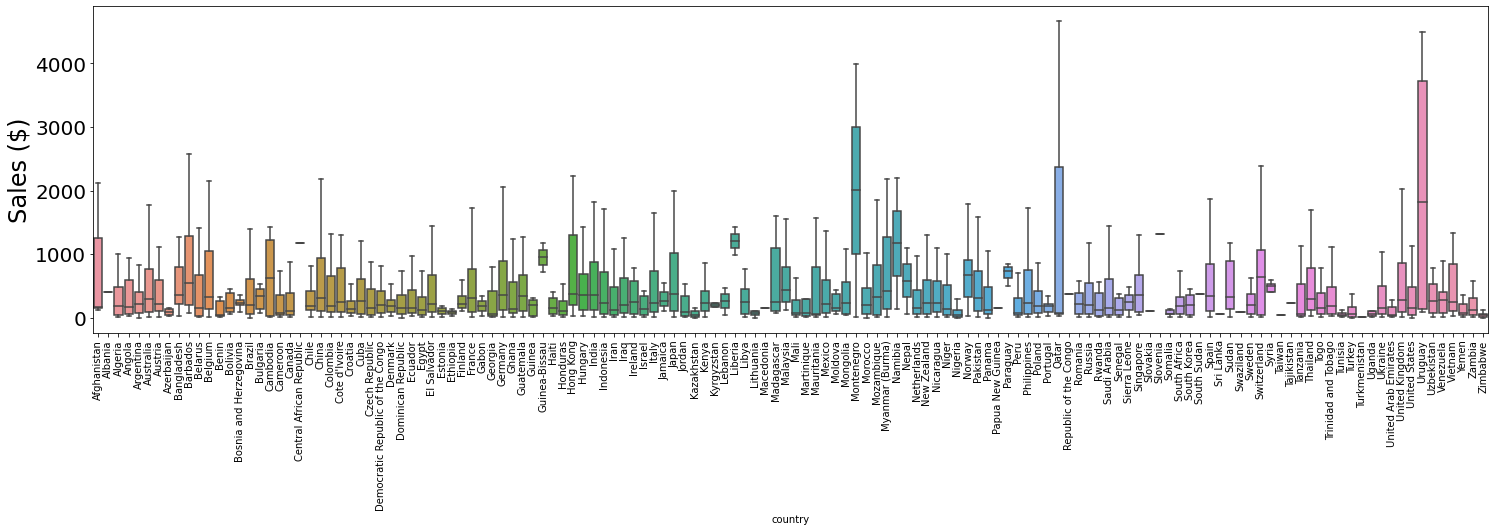

In [7]:
fig(25, 6)
sns.boxplot(data=transactions, x='country', y='sales', showfliers=False);
plt.ylabel("Sales ($)", size=24)
# plt.ylim(-10, 1500)
plt.xticks(rotation=90);
plt.yticks(size=20);

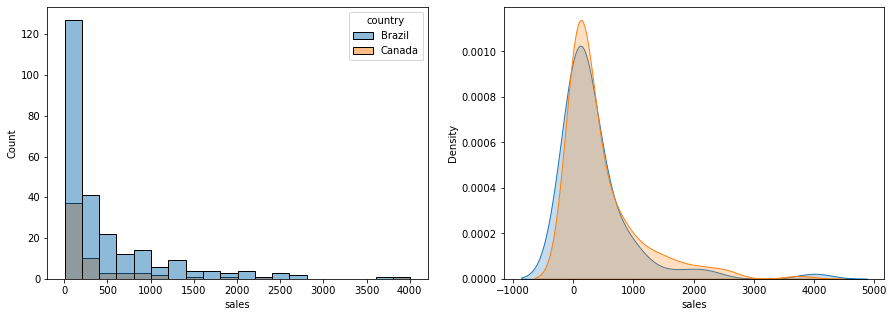

In [8]:
fig()
c = ['Canada', 'Brazil']
plt.subplot(1,2,1)
sns.histplot(data=transactions[transactions['country'].isin([c[0], c[1]])], x='sales', hue='country', bins=20);
plt.subplot(1,2,2)
sns.kdeplot(transactions[transactions['country'] == c[0]]['sales'], label=c[0], shade=True)
sns.kdeplot(transactions[transactions['country'] == c[1]]['sales'], label=c[1], shade=True);

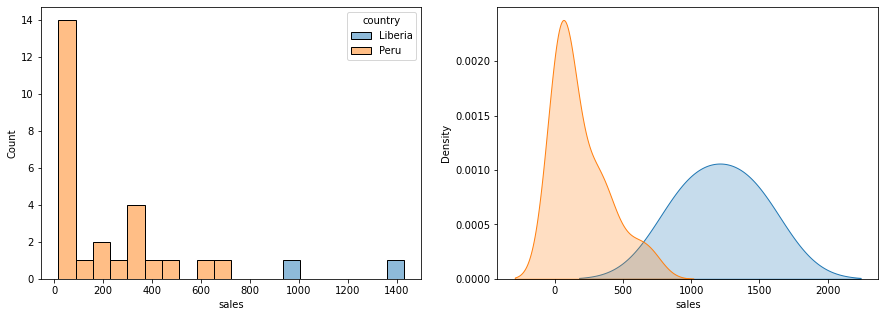

In [9]:
fig()
c = ['Liberia', 'Peru']
plt.subplot(1,2,1)
sns.histplot(data=transactions[transactions['country'].isin([c[0], c[1]])], x='sales', hue='country', bins=20);
plt.subplot(1,2,2)
sns.kdeplot(transactions[transactions['country'] == c[0]]['sales'], label=c[0], shade=True)
sns.kdeplot(transactions[transactions['country'] == c[1]]['sales'], label=c[1], shade=True);

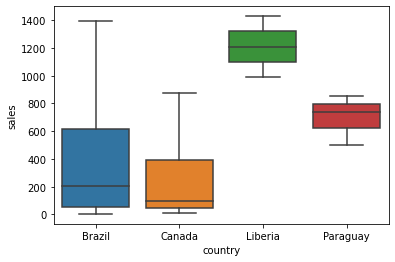

In [10]:
cs = ['Brazil', 'Canada', 'Paraguay', 'Liberia']
sns.boxplot(data=transactions[transactions['country'].isin(cs)], x='country', y='sales', showfliers=0);

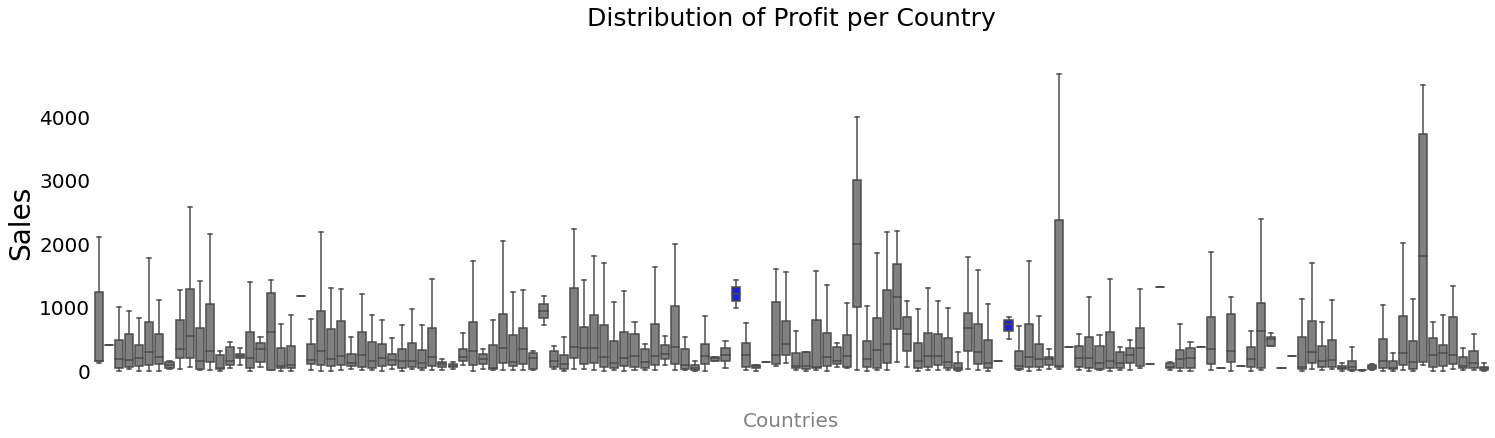

In [11]:
fig(25, 6)
custom_palette = {}
for country_ in set(transactions['country']):
    blue_list = ['Paraguay', 'Liberia']
    if country_ in blue_list:
        custom_palette[country_] = 'blue'
    else:
        custom_palette[country_] = 'grey'
        
plt.box(False)
sns.boxplot(data=transactions, x='country', y='sales', palette=custom_palette, showfliers=False)
plt.title("Distribution of Profit per Country\n", size=25)
plt.xlabel("\nCountries", size=20, color='grey')
plt.ylabel("Sales", size=28)
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='black', size=20)
plt.xticks([]);

In [12]:
# fig(25, 6)
# sns.boxplot(data=transactions, x='country', y='profit', showfliers=False);
# plt.ylabel("Profit ($)", size=24)
# # plt.ylim(-500, 700)
# plt.xticks([]);

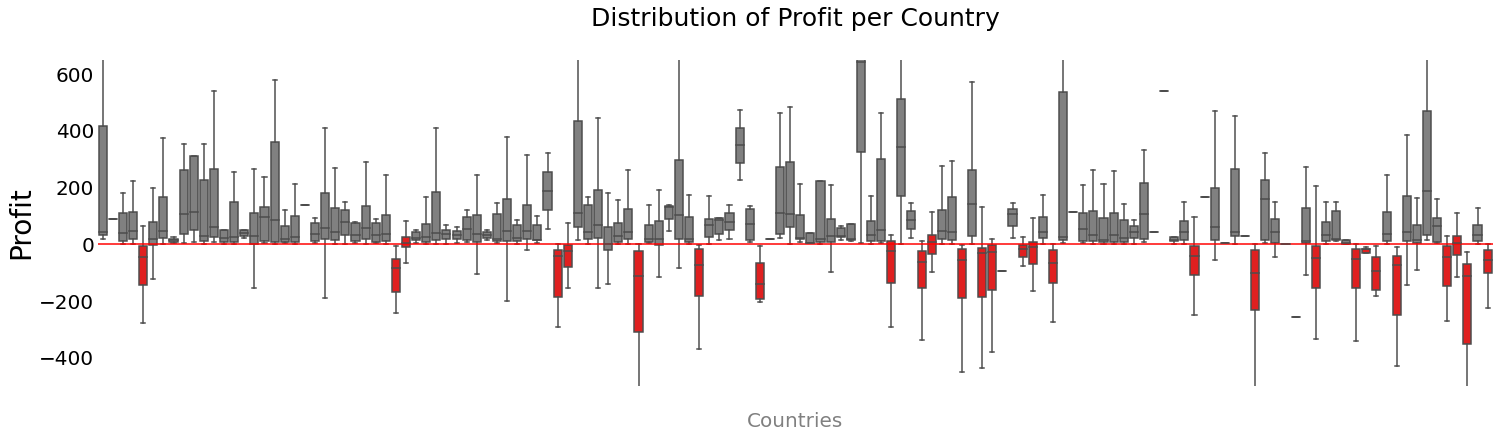

In [13]:
fig(25, 6)
custom_palette = {}
for country_ in set(transactions['country']):
    profit = (np.sum(transactions[transactions['country'] == country_]['profit']))
    if profit < 0:
        custom_palette[country_] = 'red'
    else:
        custom_palette[country_] = 'grey'
        
plt.box(False)
sns.boxplot(data=transactions, x='country', y='profit', palette=custom_palette, showfliers=False)
plt.axhline(0, color='r')
plt.title("Distribution of Profit per Country\n", size=25)
plt.xlabel("\nCountries", size=20, color='grey')
plt.ylabel("Profit", size=28)
plt.ylim(-500, 650)
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='black', size=20)
plt.xticks([]);

### 1.2 Sales and Profit per Country

In [14]:
sales_per_country = transactions.groupby('country')[['sales', 'profit']].sum()

In [15]:
sales_per_country['group'] = sales_per_country['profit'].apply(lambda x: "Deficit" if x <= 0 else "Profit")
sales_per_country['sales_percentage'] = round(sales_per_country['sales'] / sales_per_country['sales'].sum() *100, 2)
sales_per_country.head()

,sales,profit,group,sales_percentage
country,,,,
Afghanistan,6629.28000,2093.28000,Profit,0.15
Albania,411.21000,87.51000,Profit,0.01
Algeria,12784.20000,3429.18000,Profit,0.30
Angola,8044.56000,2304.51000,Profit,0.19
Argentina,23779.54512,-7874.81488,Deficit,0.55


30 countries that in the end of the year have negative profit.

In [16]:
sales_per_country['group'].value_counts()

Profit     108
Deficit     30
Name: group, dtype: int64

**Deficit group is responsable for 10.7% of annual revenue.** 

In [17]:
sales_per_country.groupby("group")[['sales']].sum() / sales_per_country['sales'].sum()

,sales
group,
Deficit,0.107069
Profit,0.892931


In [18]:
# sales_per_country.to_parquet(join_paths([directory.DATA_DIR, "processed", f"country_profit_segmentation_{year}.parquet"]))

<font color='grey'><strong>The next step is to find out why this is happening and what can We the company do to avoid this situation. Does this deficit comes from certain products, category, or region? Let's investigate, just like a detective.</strong><br><br>
The other option is: unless We have specific questions to aks the data we can use a clustering algorithm do that for us.</font>

### 1.3 Transactions by Country Analytical Base Table

In [19]:
aggregation = {
    'ship_mode':'unique',
    'order_priority':'unique',
    'segment':'unique',
    'category':'unique',
    'customer_id':'unique',
    'city':'unique',
    'state':'unique',
    'market':'unique',
    'region':'unique',
    'category':'unique',
    'sub_category':'unique',
    'product_id':'unique',
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean',
    'shipping_cost':'sum',
    'cost':'sum',
    'sales_without_discount':'sum',
    'shipping_cost':'sum',
    'profit_per_product':'sum',
    'product_value':'sum',
    'product_cost':'sum',
    'order_date_year':'mean',
    'order_date_month':'mean',
    'order_date_day':'mean',
    'is_profitable_sale':'mean',    
    'order_date':'max',
}
countries = data[data['order_date_year'] == year].groupby(["country", "order_id"]).agg(aggregation).reset_index()
countries.head(2)

,country,order_id,ship_mode,order_priority,segment,category,customer_id,city,state,market,region,sub_category,product_id,sales,quantity,profit,discount,shipping_cost,cost,sales_without_discount,profit_per_product,product_value,product_cost,order_date_year,order_date_month,order_date_day,is_profitable_sale,order_date
0,Afghanistan,IN-2014-18791-TS-21205,[Standard Class],[Medium],[Corporate],[Office Supplies],[TS-21205],[Kabul],[Kabul],[APAC],[Central Asia],"[Envelopes, Labels]","[OFF-EN-10003715, OFF-LA-10000108]",143.97,8,31.95,0.0,9.45,102.57,143.97,7.65,36.841333,29.191333,2014.0,6.0,18.0,1.0,2014-06-18
1,Afghanistan,IN-2014-20415-GM-14455,[Standard Class],[Medium],[Home Office],"[Furniture, Office Supplies]",[GM-14455],[Kabul],[Kabul],[APAC],[Central Asia],"[Bookcases, Fasteners]","[FUR-BO-10002204, OFF-FA-10004027]",2115.51,9,850.86,0.0,187.81,1076.84,2115.51,170.28,387.668000,217.388000,2014.0,1.0,8.0,1.0,2014-01-08


In [20]:
get_value = lambda x: x[0] if len(x)<=1 else 'Mix'
columns = ['ship_mode','order_priority','segment','category','city',
           'state','market','region', 'sub_category','customer_id', 'product_id']
for col in columns:
    countries[col] = countries[col].apply(get_value)
countries.head(3)

,country,order_id,ship_mode,order_priority,segment,category,customer_id,city,state,market,region,sub_category,product_id,sales,quantity,profit,discount,shipping_cost,cost,sales_without_discount,profit_per_product,product_value,product_cost,order_date_year,order_date_month,order_date_day,is_profitable_sale,order_date
0,Afghanistan,IN-2014-18791-TS-21205,Standard Class,Medium,Corporate,Office Supplies,TS-21205,Kabul,Kabul,APAC,Central Asia,Mix,Mix,143.97,8,31.95,0.0,9.45,102.57,143.97,7.65,36.841333,29.191333,2014.0,6.0,18.0,1.0,2014-06-18
1,Afghanistan,IN-2014-20415-GM-14455,Standard Class,Medium,Home Office,Mix,GM-14455,Kabul,Kabul,APAC,Central Asia,Mix,Mix,2115.51,9,850.86,0.0,187.81,1076.84,2115.51,170.28,387.668000,217.388000,2014.0,1.0,8.0,1.0,2014-01-08
2,Afghanistan,IN-2014-26953-JG-15115,First Class,Medium,Consumer,Office Supplies,JG-15115,Kabul,Kabul,APAC,Central Asia,Art,OFF-AR-10001965,160.20,6,35.10,0.0,18.20,106.90,160.20,5.85,23.666667,17.816667,2014.0,10.0,24.0,1.0,2014-10-24


In [21]:
countries['location'] = countries['region'] + ' - ' + countries['country'] + ' - ' +\
                          countries['state'] + ' - ' + countries['city']

In [22]:
countries = countries.merge(sales_per_country.reset_index()[['country','group']], on='country')

### 1.3.1. Analysis

#### Categorial Variables

We are looking for differences...

        for example, if ship_mode of "Deficit" group is only or mainly First Class, 
        then the logistic costs may be the reason for negtive profit.
        
> Canada, West and East Regions have only "Profit" countries
>
> Canada and US Markets have only "Profit" countries

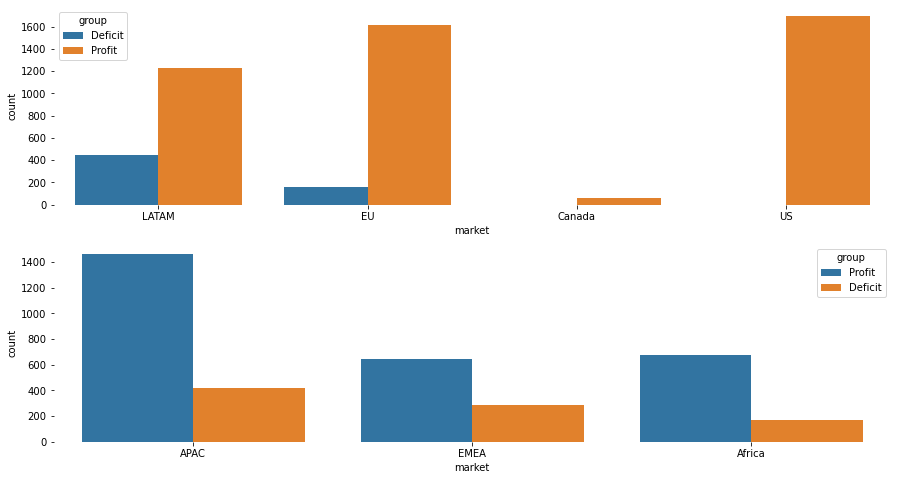

In [23]:
# ['ship_mode', 'order_priority', 'segment', 'category', 'category', 'region'*, 'market'*, 'sub_category',]
# city and state have too many categories to plot at once

category = 'market'

length = int(len(countries[category].unique())/2)
aux = countries[countries[category].isin(countries[category].unique()[length:])]
aux2 = countries[countries[category].isin(countries[category].unique()[:length])]

fig(15, 8)

plt.subplot(2, 1, 1)
sns.countplot(x=category, hue='group', data=aux, dodge=1,)
plt.box(False)

plt.subplot(2, 1, 2)
sns.countplot(x=category, hue='group', data=aux2, dodge=1)
plt.box(False)

In [24]:
# fig(15,5)
# sns.countplot(x='market', hue='group', data=countries);

#### City and State

    Now We have the cities with most unprofitable orders. And later We can analyze them and try to
    figure out why is that...

In [25]:
deficit_cities = countries.loc[countries['group'] == 'Deficit', ['city', 'is_profitable_sale']].groupby('city').agg(['mean', 'count'])
profit_cities = countries.loc[countries['group'] == 'Profit', ['city', 'is_profitable_sale']].groupby('city').agg(['mean', 'count'])

profit_cities = profit_cities.reset_index()
profit_cities.columns = ['city', 'profit_is_profitable', 'profit_orders']
deficit_cities = deficit_cities.reset_index()
deficit_cities.columns = ['city', 'deficit_is_profitable', 'deficit_orders']

cities = profit_cities.merge(deficit_cities, how='outer').fillna(0)

In [26]:
cities.sort_values('deficit_orders', ascending=False).head()

,city,profit_is_profitable,profit_orders,deficit_is_profitable,deficit_orders
2368,Manila,0.0,0.0,0.350763,78.0
2451,Santo Domingo,0.0,0.0,0.569737,76.0
2473,Tegucigalpa,0.0,0.0,0.123016,66.0
2319,Istanbul,0.0,0.0,0.000000,62.0
2350,Lagos,0.0,0.0,0.000000,52.0


In [27]:
cities['deficit_orders_percent'] = cities['deficit_orders'] / (cities['profit_orders'] + cities['deficit_orders'])
cities.sort_values('deficit_orders', ascending=False).head()

,city,profit_is_profitable,profit_orders,deficit_is_profitable,deficit_orders,deficit_orders_percent
2368,Manila,0.0,0.0,0.350763,78.0,1.0
2451,Santo Domingo,0.0,0.0,0.569737,76.0,1.0
2473,Tegucigalpa,0.0,0.0,0.123016,66.0,1.0
2319,Istanbul,0.0,0.0,0.000000,62.0,1.0
2350,Lagos,0.0,0.0,0.000000,52.0,1.0


In [28]:
cities.to_parquet(join_paths([directory.DATA_DIR, "processed", 'country_segmentation', "cities_profit_table.parquet"]))

#### Numerical Variables

> Deficit group: 75% of discounts are greater than 40%.
>
> Deficit group: 75% of transactions generate deficit.

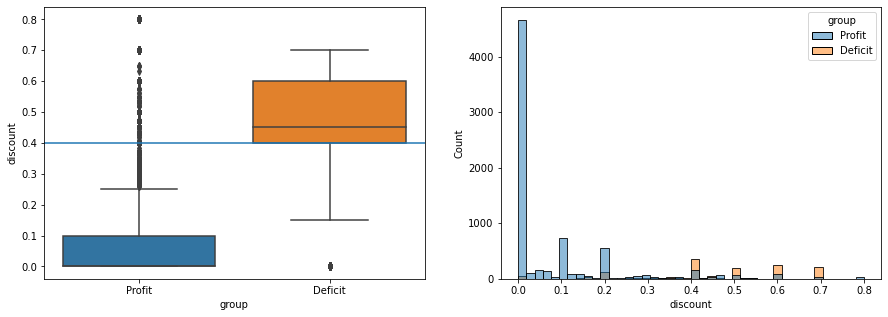

In [29]:
# ['sales', 'profit', 'quantity', 'discount'*, 'shipping_cost', ]


fig(15, 5)
plt.subplot(1, 2, 1)

sns.boxplot(x='group', y='discount', data=countries, showfliers=1); 
plt.axhline(0.4)

plt.subplot(1, 2, 2)
sns.histplot(data=countries, x='discount', hue='group');
# plt.xlim(-200, 200);

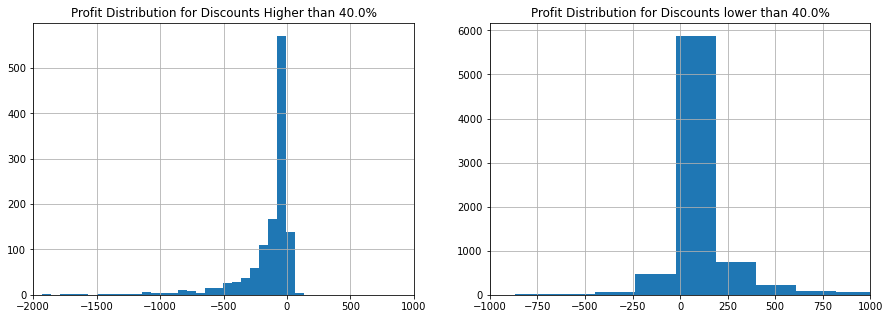

In [30]:
discount_value = 0.4
fig(15, 5)
plt.subplot(1, 2, 1)
countries[countries['discount'] > discount_value]['profit'].hist(bins=50)
plt.title(f"Profit Distribution for Discounts Higher than {discount_value*100}%")
plt.xlim(-2000, 1000)
plt.subplot(1, 2, 2)
countries[countries['discount'] <= discount_value]['profit'].hist(bins=50);
plt.title(f"Profit Distribution for Discounts lower than {discount_value*100}%")
plt.xlim(-1000, 1000);

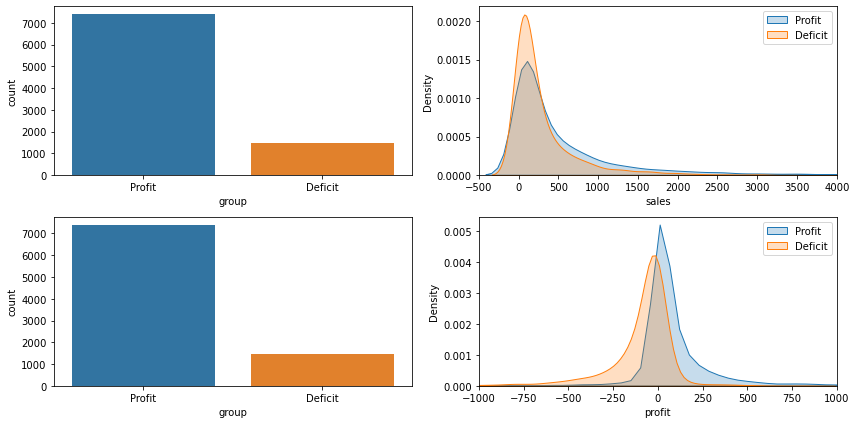

In [31]:
category = ['group', 'group']
classes1 = ['Profit', 'Deficit']
classes2 = ['Profit', 'Deficit']

fig(12, 6)

# categorical attribute 1
plt.subplot( 2, 2, 1 )
sns.countplot(x=countries[category[0]])

plt.subplot( 2, 2, 2 )
sns.kdeplot(countries[countries[category[0]] == classes1[0]]['sales'], label=classes1[0], shade=True)
sns.kdeplot(countries[countries[category[0]] == classes1[1]]['sales'], label=classes1[1], shade=True)
plt.xlim(-500, 4000)
plt.legend()

# categorical attribute 2
plt.subplot(2, 2, 3 )
sns.countplot(x=countries[category[1]])

plt.subplot( 2, 2, 4 )
sns.kdeplot(countries[countries[category[1]] == classes2[0]]['profit'], label=classes2[0], shade=True)
sns.kdeplot(countries[countries[category[1]] == classes2[1]]['profit'], label=classes2[1], shade=True)
plt.xlim(-1000, 1000)
plt.legend()

plt.tight_layout()

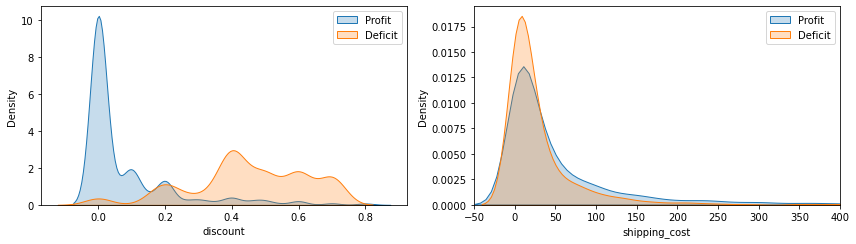

In [32]:
classes1 = ['Profit', 'Deficit']
classes2 = ['Profit', 'Deficit']
y_variables = ['discount', 'shipping_cost']

fig(12, 3.5)

# categorical attribute 1
plt.subplot( 1, 2, 1 )
sns.kdeplot(countries[countries[category[0]] == classes1[0]][y_variables[0]], label=classes1[0], shade=True)
sns.kdeplot(countries[countries[category[0]] == classes1[1]][y_variables[0]], label=classes1[1], shade=True)
plt.legend()

# categorical attribute 2
plt.subplot( 1, 2, 2 )
sns.kdeplot(countries[countries[category[1]] == classes2[0]][y_variables[1]], label=classes2[0], shade=True)
sns.kdeplot(countries[countries[category[1]] == classes2[1]][y_variables[1]], label=classes2[1], shade=True)
plt.xlim(-50, 400)
plt.legend()

plt.tight_layout()

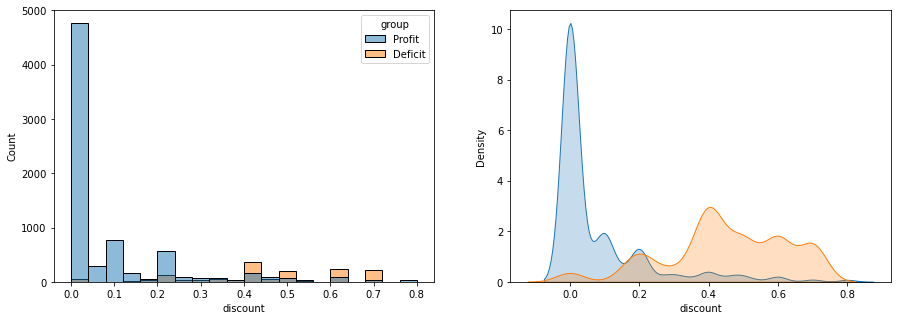

In [33]:
fig()
plt.subplot(1,2,1)
sns.histplot(data=countries, x='discount', hue='group', bins=20);
plt.subplot(1,2,2)
sns.kdeplot(countries[countries['group'] == classes1[0]]['discount'], label=classes1[0], shade=True)
sns.kdeplot(countries[countries['group'] == classes1[1]]['discount'], label=classes1[1], shade=True);

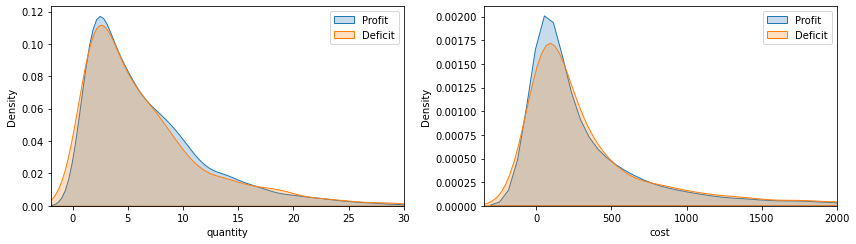

In [34]:
category = ['group', 'group']
classes1 = ['Profit', 'Deficit']
classes2 = ['Profit', 'Deficit']
y_variables = ['quantity', 'cost']

fig(12, 3.5)

# categorical attribute 1
plt.subplot( 1, 2, 1 )
sns.kdeplot(countries[countries[category[0]] == classes1[0]][y_variables[0]], label=classes1[0], shade=True)
sns.kdeplot(countries[countries[category[0]] == classes1[1]][y_variables[0]], label=classes1[1], shade=True)
plt.xlim(-2, 30)
plt.legend()

# categorical attribute 2
plt.subplot( 1, 2, 2 )
sns.kdeplot(countries[countries[category[1]] == classes2[0]][y_variables[1]], label=classes2[0], shade=True)
sns.kdeplot(countries[countries[category[1]] == classes2[1]][y_variables[1]], label=classes2[1], shade=True)
plt.xlim(-350, 2000)
plt.legend()

plt.tight_layout()

##### discount

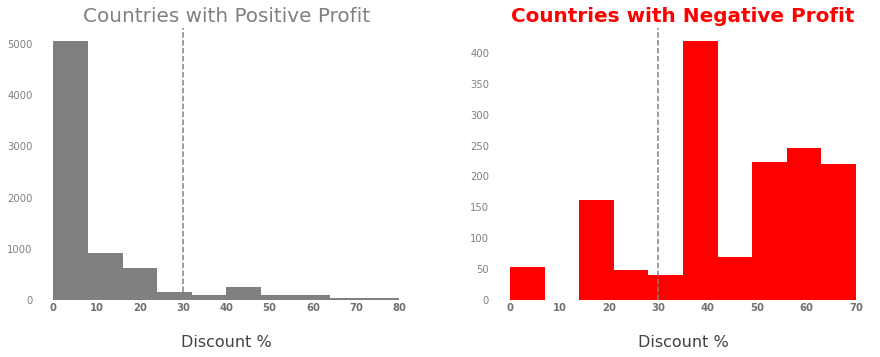

In [35]:
plt.subplot( 1, 2, 1 )
plt.box(False)
(countries[countries['group'] == 'Profit']['discount']*100).hist(figsize=(15,5), color='grey')
plt.tick_params(axis='both', which='both', length=0)
plt.grid(None)
plt.title('Countries with Positive Profit', color='grey', size=20)
plt.xlabel("\nDiscount %", size=16, color='#424242')
plt.yticks(color='grey')
plt.xticks(color='#707070', weight='bold')
plt.axvline(30, color='grey', ls='--')

plt.subplot( 1, 2, 2 )
plt.box(False)
(countries[countries['group'] == 'Deficit']['discount']*100).hist(color='red')
plt.tick_params(axis='both', which='both', length=0)
plt.grid(None)
plt.title('Countries with Negative Profit', color='red', weight='bold', size=20)
plt.xlabel("\nDiscount %", size=16, color='#424242')
plt.yticks(color='grey')
plt.xticks(color='#707070', weight='bold')
plt.axvline(30, color='grey', ls='--');

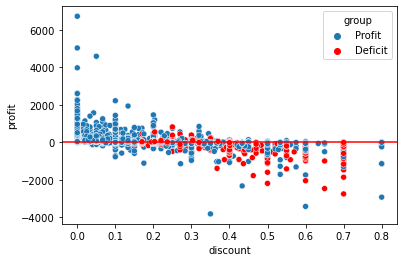

In [36]:
sns.scatterplot(data=countries, x='discount', y='profit', hue='group', palette=['#1f77b4', 'red'])
plt.axhline(0, color='r');

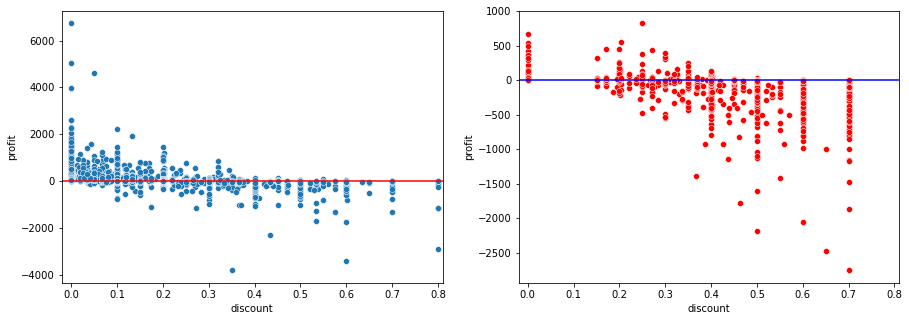

In [37]:
fig(15, 5)
plt.subplot(1,2,1)
sns.scatterplot(data=countries[countries['group'] == 'Profit'], x='discount', y='profit')
plt.axhline(0, color='r');
plt.xlim(-0.02, 0.81);
plt.subplot(1,2,2)
sns.scatterplot(data=countries[countries['group'] == 'Deficit'], x='discount', y='profit', color='red')
plt.axhline(0, color='blue')
plt.xlim(-0.02, 0.81);

Classified as Deficit, but neither Profit or Defict

In [38]:
len(countries[(countries['group'] == 'Deficit') & (countries['profit'] >= 0)]) / len(countries[(countries['group'] == 'Deficit')])

0.17960837272113436

##### shipping_cost

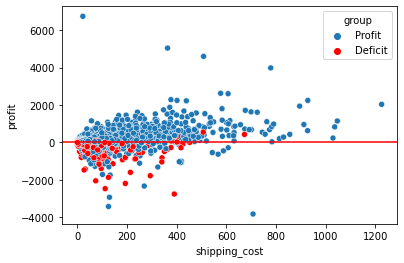

In [39]:
sns.scatterplot(data=countries, x='shipping_cost', y='profit', hue='group', palette=['#1f77b4', 'red'])
plt.axhline(0, color='r');

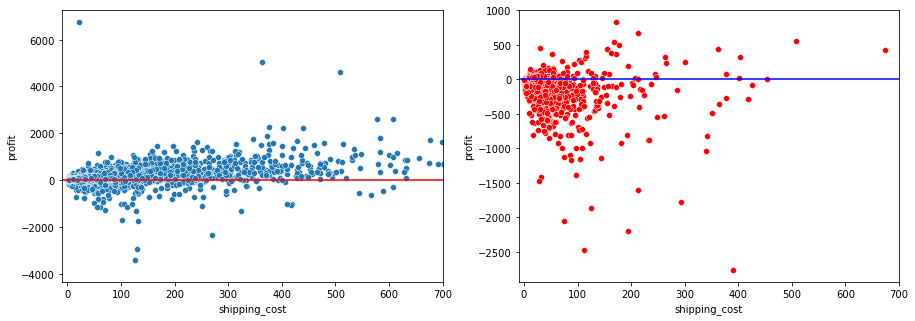

In [40]:
fig(15, 5)
plt.subplot(1,2,1)
sns.scatterplot(data=countries[countries['group'] == 'Profit'], x='shipping_cost', y='profit')
plt.xlim(-10, 700)
plt.axhline(0, color='r');
plt.subplot(1,2,2)
sns.scatterplot(data=countries[countries['group'] == 'Deficit'], x='shipping_cost', y='profit', color='red')
plt.axhline(0, color='blue')
plt.xlim(-10, 700);

## 2 Clustering Algorithm

**We can cluster the transactions by countries** or We can cluster the customers and later group them by country.

### 2.1 Feature Engineering

In [41]:
cities = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", 'country_segmentation', "cities_profit_table.parquet"]))
cities.columns = cities.columns.map(lambda x: 'city_'+x if x != 'city' else x)

In [42]:
countries = countries.merge(cities)

In [43]:
df = countries.copy()
df.select_dtypes(include=['int', 'float']).columns

Index(['sales', 'quantity', 'profit', 'discount', 'shipping_cost', 'cost',
       'sales_without_discount', 'profit_per_product', 'product_value',
       'product_cost', 'order_date_year', 'order_date_month', 'order_date_day',
       'is_profitable_sale', 'city_profit_is_profitable', 'city_profit_orders',
       'city_deficit_is_profitable', 'city_deficit_orders',
       'city_deficit_orders_percent'],
      dtype='object')

In [44]:
columns = ['ship_mode','order_priority','segment','category','city','state','market','region', 'sub_category']
df[columns] = df[columns].apply(LabelEncoder().fit_transform)

cols = ['ship_mode', 'order_priority', 'segment', 'category', 'city', 'state',
        'market', 'region', 'sub_category', 'sales', 'quantity', 'profit', 'discount',
        'shipping_cost', 'cost', 'sales_without_discount', 'profit_per_product', 'product_value',
       'product_cost', 'order_date_year', 'order_date_month', 'order_date_day',
       'is_profitable_sale', 'city_profit_is_profitable', 'city_profit_orders',
       'city_deficit_is_profitable', 'city_deficit_orders', 'city_deficit_orders_percent']
min_max_scaler = MinMaxScaler()
df[cols] = min_max_scaler.fit_transform(df[cols])

X = df[cols].copy()

In [45]:
features = ['ship_mode', 'order_priority', 'segment', 'category', 'city', 'state',
            'market', 'region', 'sub_category', 'sales', 'quantity', 'profit', 'discount',
            'shipping_cost', 'cost', 'sales_without_discount', 'profit_per_product', 'product_value',
            'product_cost', 'order_date_year', 'order_date_month', 'order_date_day',
            'is_profitable_sale', 'city_profit_is_profitable', 'city_profit_orders',
            'city_deficit_is_profitable', 'city_deficit_orders', 'city_deficit_orders_percent']

features = ['ship_mode', 'order_priority', 'segment', 'category', 'city', 'state',
            'market', 'region', 'sub_category', 'sales', 'quantity', 'profit', 'discount',
            'shipping_cost', 'cost', 'product_value',
            'city_profit_is_profitable', 'city_profit_orders',
            'city_deficit_is_profitable', 'city_deficit_orders', 'city_deficit_orders_percent']


# X[features]

In [46]:
# X_kmodes = countries.drop(columns=['order_id', 'customer_id', 'order_date', 'group', 'order_date_year',
#                         'order_date_month','order_date_day','is_profitable_sale', 'location', 'cluster'])

# X_kmodes = countries[features]
# cols = X_kmodes.select_dtypes(include=['int', 'float']).columns

# min_max_scaler = MinMaxScaler()
# X_kmodes[cols] = min_max_scaler.fit_transform(X_kmodes[cols])


# X_kmodes = countries.select_dtypes(exclude=['int', 'float']).drop(columns=['order_id', 'customer_id', 'order_date',
#                                                                            'group', 'cluster', 'location'])

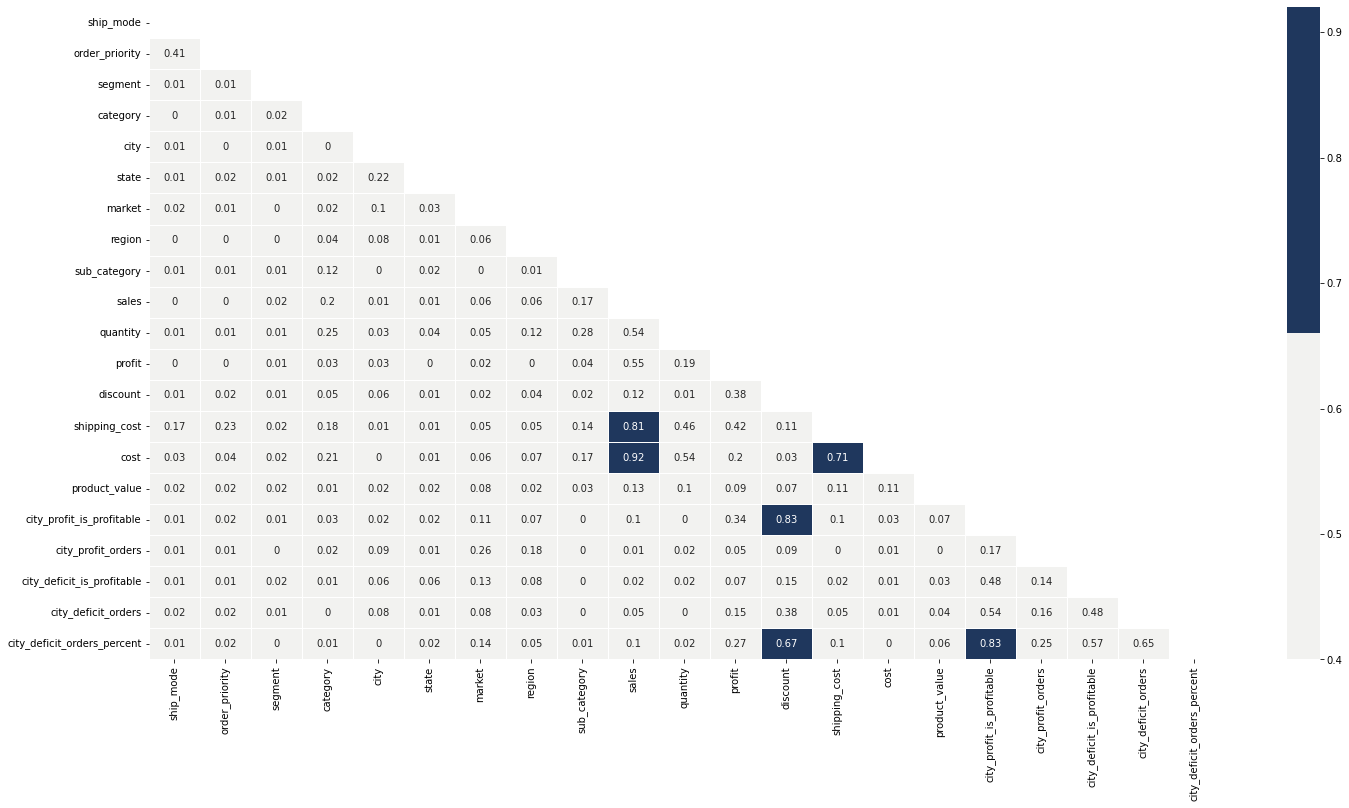

In [47]:
plt.figure(figsize=(24, 12))
correlations = X[features].corr().abs().round(2)
mask = np.triu(np.ones_like(correlations, dtype=bool))
sns.heatmap(correlations, mask=mask, linewidths=1, annot=True, cmap=['#F2F2F0','#1F375D'], vmin=0.40) #vmax=-0.40
plt.show()

## 2.2 Algorithm

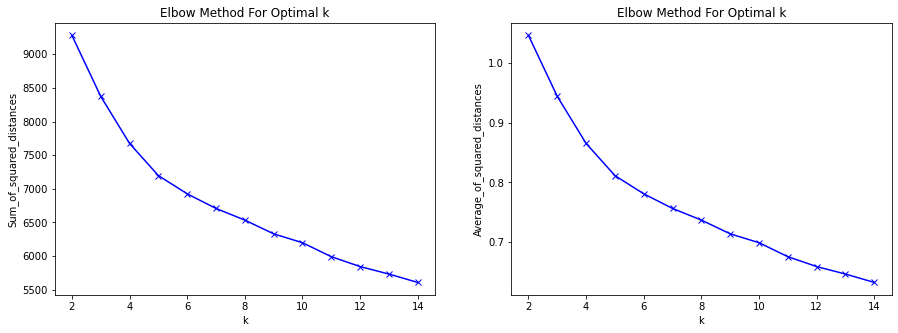

Wall time: 8.04 s


In [48]:
%%time
sum_of_squared_distances = []
average_of_squared_distances = []

K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k, max_iter=500, random_state=42)
    km = km.fit(X[features])
    sum_of_squared_distances.append(km.inertia_) 
    
    distortion = ((X[features] - km.cluster_centers_[km.predict(X[features])])**2.0).sum(axis=1).mean()
    average_of_squared_distances.append(distortion)
     
plt.figure(figsize=(15, 5))
plt.subplot( 1, 2, 1 )
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.subplot( 1, 2, 2 )
plt.plot(K, average_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Average_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

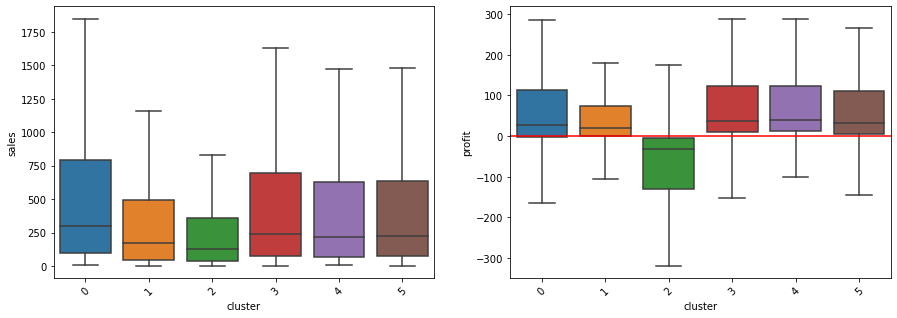

In [49]:
kmeans = KMeans(n_clusters=6, max_iter=500, random_state=42)
labels = kmeans.fit_predict(X[features])
countries['cluster'] = labels


# dbscan = DBSCAN(eps=.23, min_samples=10, ).fit(X[features]) # eps=.5, min_samples=15
# countries['cluster'] = dbscan.labels_


# kmodes = KModes(n_clusters = 6, init = 'Cao', random_state = 0)
# countries['cluster'] = kmodes.fit_predict(X_kmodes)


boxplot( cluster='cluster', y=['sales', 'profit'], data=countries, xticks_rotation=45)
plt.axhline(0, color='r');

## 2.3 Analysis

ps: Result's not good enough.

### 0

    Regions: Only Found in Oceania, Southeast Asia, North Asia, Central Asia, 

    Ship Mode: Standard Class, Second Class, Same Day
    
    Market: Only Found in APAC
    

### 1

    Regions: Only Found in South, North, Central,  West, East
    Segment: Corporate, Consumer
    
    Ship Mode: Standard Class, Second Class, Same Day
    
    Market: Only Found in LATAM, US ,EU
    

### 2

    75% of transactions have Profit lower than 0.
    75% of transactions have Discounts greater than 40%.

    Regions: not Found in Canada, West, East.       
             Most Profitable Regions?
     
    Market: Not Found in Canada, US
    

### 3
    
    85% of transactions have Discounts lower than 10%.
    
    Regions: not Found in Southeast Asia, Ocenia.
    
    Segment: Home Office, Corporate
    
    Ship Mode: Standard Class, Second Class, Same Day

### 4

    90% of transactions have Discounts lower than 5%.
    
    Regions: Not Found in South, Oceania, Southeast Asia, West, East
    
    Segment: Corporate, Consumer
    
    Ship Mode: Standard Class, Second Class, Same Day
    
    Market: Not Found in US
    

### 5

    Ship Mode: Same Day, First Class
    
    Order Priority is never low


### 2.3.1 Numerical Variables

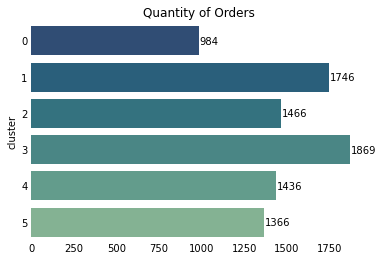

In [50]:
count_plot(countries, cluster_col="cluster", palette='crest_r', title='Quantity of Orders');

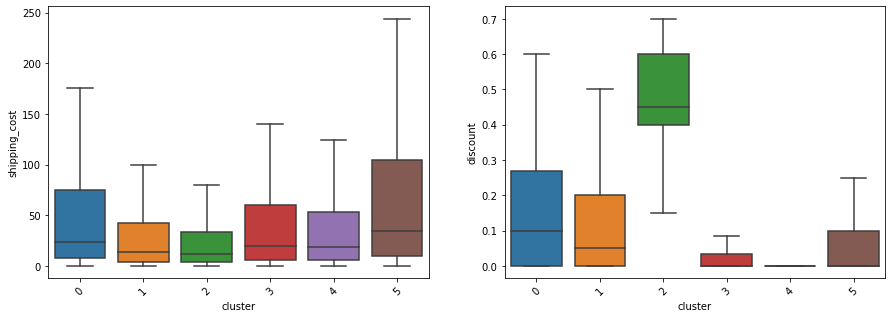

In [51]:
boxplot( cluster='cluster', y=['shipping_cost', 'discount'], data=countries, xticks_rotation=45, showfliers=0)

In [52]:
cluster_stats(countries, 'discount', quantile_1=.85)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
0,0.145043,0.156057,0.0,0.0,0.10,0.270000,0.400,0.40,0.6
1,0.143007,0.197084,0.0,0.0,0.05,0.200000,0.325,0.45,0.8
2,0.450755,0.175715,0.0,0.4,0.45,0.600000,0.600,0.70,0.7
3,0.046375,0.113052,0.0,0.0,0.00,0.033333,0.100,0.20,0.8
4,0.011391,0.036168,0.0,0.0,0.00,0.000000,0.000,0.05,0.4
5,0.077499,0.141780,0.0,0.0,0.00,0.100000,0.200,0.20,0.8


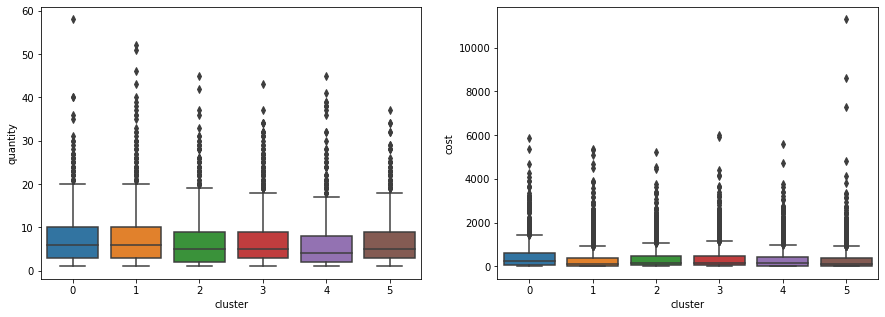

In [53]:
boxplot( cluster='cluster', y=['quantity', 'cost'], data=countries, showfliers=45)

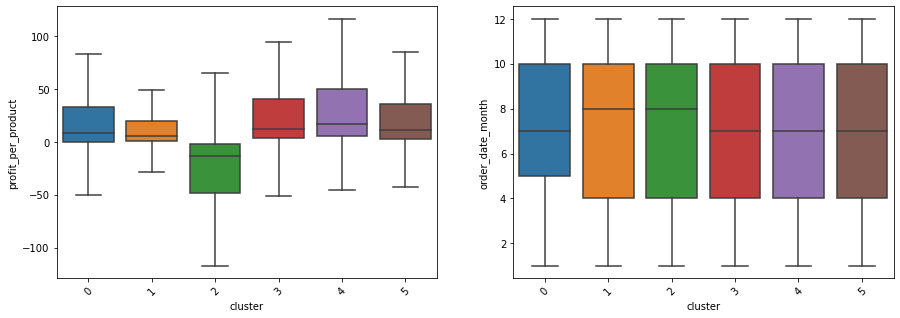

In [54]:
boxplot( cluster='cluster', y=['profit_per_product', 'order_date_month'], data=countries, xticks_rotation=45)

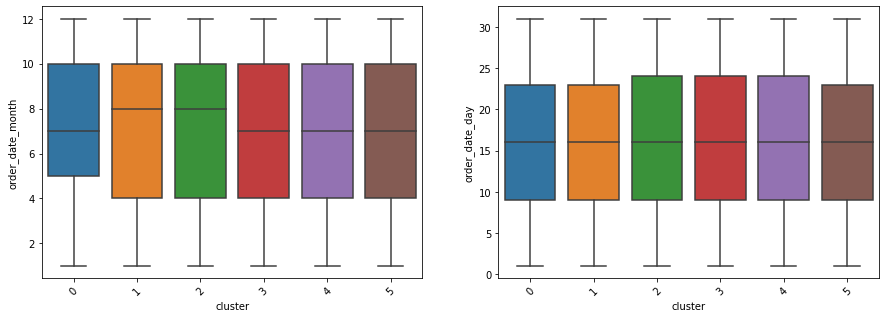

In [55]:
boxplot( cluster='cluster', y=['order_date_month', 'order_date_day'], data=countries, xticks_rotation=45)

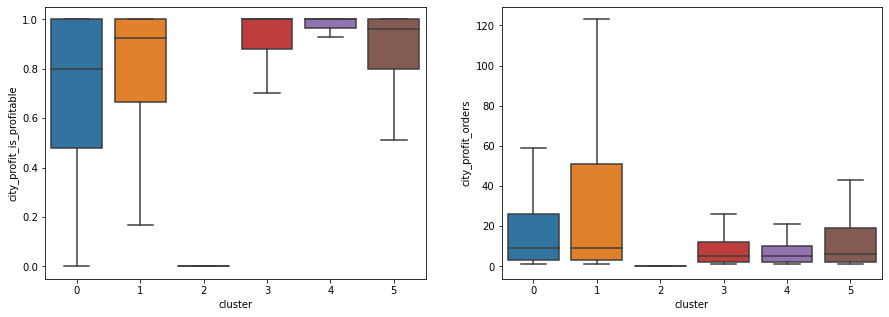

In [56]:
boxplot( cluster='cluster', y=['city_profit_is_profitable', 'city_profit_orders'], data=countries)

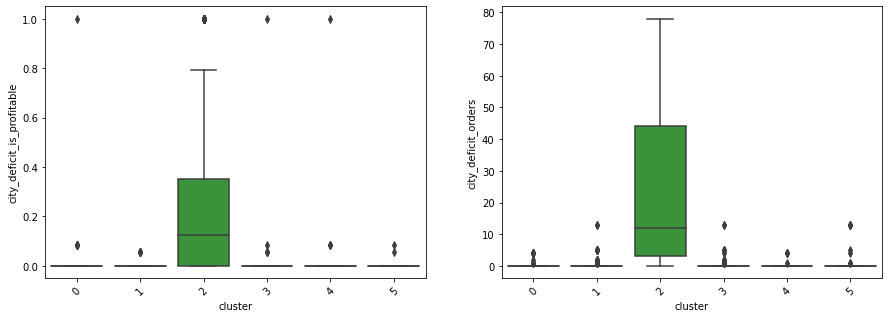

In [57]:
boxplot(cluster='cluster', y=['city_deficit_is_profitable', 'city_deficit_orders'], showfliers=1,
        data=countries, xticks_rotation=45)

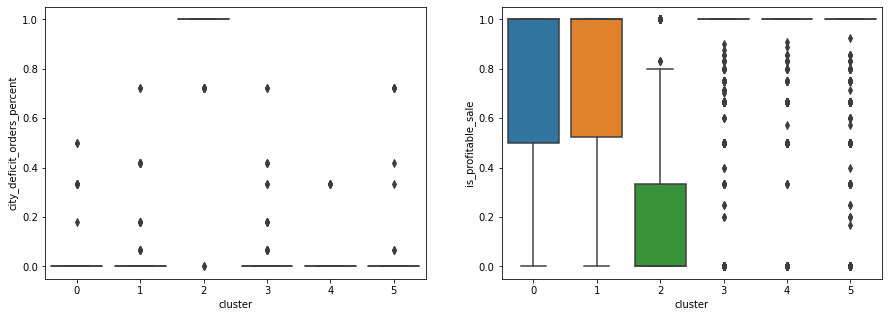

In [58]:
boxplot( cluster='cluster', y=['city_deficit_orders_percent', 'is_profitable_sale'], data=countries, showfliers=45)

### 2.3.2 Categorical Variables

[Random Forest](#3.1-Random-Forest)

```python
feature_importances.index # ['region', 'segment', 'ship_mode', 'market']
```

In [59]:
# ['order_priority', 'category', 'sub_category',]

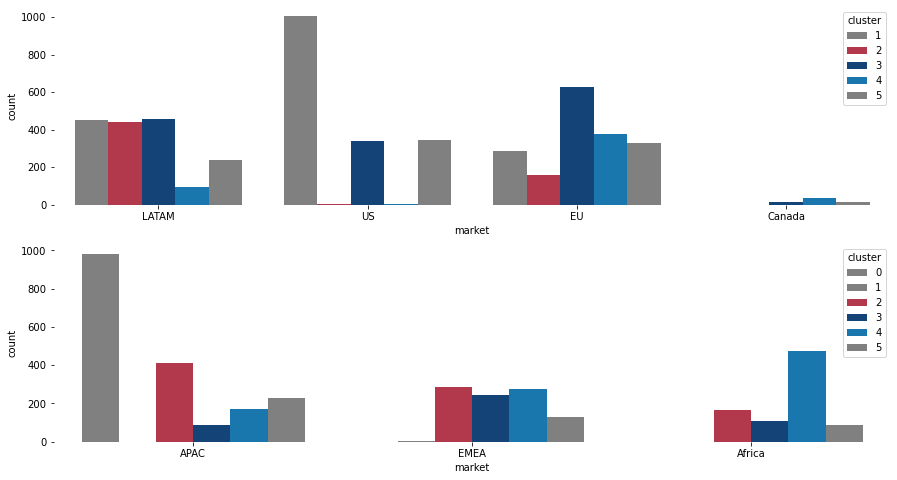

In [60]:
category = 'market'
cluster = [3,4, 2]

length = int(len(countries[category].unique())/2)
aux = countries[countries[category].isin(countries[category].unique()[length:])]
aux2 = countries[countries[category].isin(countries[category].unique()[:length])]

fig(15, 8)

plt.subplot(2, 1, 1)
sns.countplot(x=category, hue='cluster', data=aux, dodge=1, palette=get_cluster_palette(cluster))
plt.box(False)

plt.subplot(2, 1, 2)
sns.countplot(x=category, hue='cluster', data=aux2, dodge=1, palette=get_cluster_palette(cluster))
plt.box(False)

## 3 Classifying Clusters

### 3.1 Random Forest

In [61]:
# X = countries.select_dtypes(include=[int, float]).drop(columns=['cluster'])


# X = countries.drop(columns=['cluster', 'order_id', 'customer_id', 'location', 'group',
                            
#                             'order_date_year', 'category', 'sub_category', 'order_date_month',
#                             'product_id', 'order_date_day', 'quantity', 'order_date', 'cost',
#                             'sales', 'is_profitable_sale', 'sales_without_discount',
#                             'product_value', 'product_cost',
                           
#                             'profit', 'state', 'city', 'discount', 'city_deficit_orders',
#                            'city_profit_is_profitable', 'group',])


X = countries[['region', 'market', 'segment', 'ship_mode', 'profit']]
y = countries['cluster']

In [62]:
cols = X.select_dtypes(exclude=[int, float]).columns

In [63]:
X.loc[:, cols] = X[cols].apply(LabelEncoder().fit_transform)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:1884: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, val, pi)


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
pd.concat([y_train.value_counts(), y_test.value_counts()], axis=1)

,cluster,cluster
0,691,293
1,1235,511
2,1047,419
3,1294,575
4,983,453
5,956,410


In [65]:
random_forest_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=0)
random_forest_model.fit(X_train, y_train)

y_pred = random_forest_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81       293
           1       0.88      0.89      0.89       511
           2       0.78      0.68      0.73       419
           3       0.92      0.91      0.91       575
           4       0.92      0.91      0.92       453
           5       0.92      0.93      0.92       410

    accuracy                           0.87      2661
   macro avg       0.86      0.87      0.86      2661
weighted avg       0.87      0.87      0.87      2661



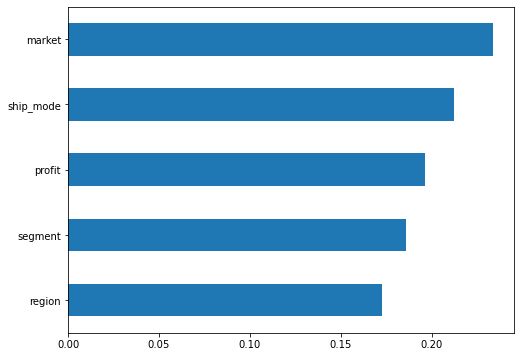

In [66]:
feature_importances = pd.Series(random_forest_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feature_importances.plot.barh(figsize=(8, 6));

In [67]:
# feature_importances.tail(14).index

## 4 Grouping Countries with Similar Transactions

In [68]:
# countries_groups = countries.loc[countries['cluster'] == 0, ['country']].value_counts(normalize=0).reset_index()

In [69]:
# cluster_number = 5
# aux = countries.loc[countries['cluster'] == cluster_number, ['country']].value_counts(normalize=0).reset_index()
# aux.columns = ['country', cluster_number]
# countries_groups = countries_groups.merge(aux, how='outer')

In [70]:
# countries_groups.fillna(0, inplace=True)
# countries_groups.head()

In [71]:
# countries_groups['quantity'] = countries_groups[0]+countries_groups[1]+countries_groups[2]+countries_groups[3]+countries_groups[4]+countries_groups[5]

# countries_groups['0%'] = countries_groups[0] / countries_groups['quantity']
# countries_groups['1%'] = countries_groups[1] / countries_groups['quantity']
# countries_groups['2%'] = countries_groups[2] / countries_groups['quantity']
# countries_groups['3%'] = countries_groups[3] / countries_groups['quantity']
# countries_groups['4%'] = countries_groups[4] / countries_groups['quantity']
# countries_groups['5%'] = countries_groups[5] / countries_groups['quantity']

In [72]:
# def classify(countries_groups):
#     c0 = countries_groups['0%']
#     c1 = countries_groups['1%']
#     c2 = countries_groups['2%']
#     c3 = countries_groups['3%']
#     c4 = countries_groups['4%']
#     c5 = countries_groups['5%']
#     cluster_percent = [c0, c1, c2, c3, c4, c5]
    
#     biggest_number = max(cluster_percent)
#     idx = cluster_percent.index(biggest_number)
    
#     if idx == 0:
#         return 0
#     elif idx == 1:
#         return 1
#     elif idx == 2:
#         return 2
#     elif idx == 3:
#         return 3
#     elif idx == 4:
#         return 4
#     elif idx == 5:
#         return 5
#     else:
#         return -1
    
# countries_groups['cluster'] = countries_groups.apply(classify, axis=1)

In [73]:
# countries_groups[countries_groups['cluster'] == -1]

In [74]:
# countries_groups[countries_groups['cluster'] == 5]

## 5 Clustering Countries

### 5.1 Countries Analytial Base Table 

In [75]:
aggregation = {
    'ship_mode':'unique',
    'order_priority':'unique',
    'segment':'unique',
    'category':'unique',
    'order_id':'nunique',
    'customer_id':'nunique',
    'product_id':'nunique',
    'city':'nunique',
    'state':'nunique',
    'region':'nunique',
    'market':'unique',    
    'category':'nunique',
    'sub_category':'nunique',
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean',
    'shipping_cost':'mean',
    'cost':'sum',
#     'sales_without_discount':'sum',
    'shipping_cost':'sum',
#     'profit_per_product':'sum',
#     'product_value':'sum',
#     'product_cost':'sum',
    'is_profitable_sale':'mean',    
#     'order_date':'max',
}
countries_abt = countries.groupby('country').agg(aggregation)
countries_abt.head(2)

,ship_mode,order_priority,segment,category,order_id,customer_id,product_id,city,state,region,market,sub_category,sales,quantity,profit,discount,shipping_cost,cost,is_profitable_sale
country,,,,,,,,,,,,,,,,,,,
Afghanistan,"[Standard Class, First Class, Second Class]","[Medium, High]","[Corporate, Home Office, Consumer]",3,9,9,5,3,3,1,[APAC],4,6629.28,76,2093.28,0.0,641.13,3894.87,1.0
Albania,[Second Class],[High],[Consumer],1,1,1,1,1,1,1,[EMEA],1,411.21,11,87.51,0.0,48.22,275.48,1.0


### 5.1.2 Feature Engineering

In [76]:
ship_mode = pd.get_dummies(countries_abt['ship_mode'].explode(), prefix='ship_mode').reset_index().groupby('country').sum()
order_priority = pd.get_dummies(countries_abt['order_priority'].explode(), prefix='order_priority').reset_index().groupby('country').sum()
segment = pd.get_dummies(countries_abt['segment'].explode(), prefix='segment').reset_index().groupby('country').sum()
market = pd.get_dummies(countries_abt['market'].explode(), prefix='market').reset_index().groupby('country').sum()

In [77]:
countries_abt = countries_abt.join(ship_mode)
countries_abt = countries_abt.join(order_priority)
countries_abt = countries_abt.join(segment)
countries_abt = countries_abt.join(market)

countries_abt.drop(columns=['ship_mode','order_priority','segment','market'], inplace=True)
countries_abt.head(2)

,category,order_id,customer_id,product_id,city,state,region,sub_category,sales,quantity,profit,discount,shipping_cost,cost,is_profitable_sale,ship_mode_First Class,ship_mode_Same Day,ship_mode_Second Class,ship_mode_Standard Class,order_priority_Critical,order_priority_High,order_priority_Low,order_priority_Medium,order_priority_Mix,segment_Consumer,segment_Corporate,segment_Home Office,market_APAC,market_Africa,market_Canada,market_EMEA,market_EU,market_LATAM,market_US
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,3,9,9,5,3,3,1,4,6629.28,76,2093.28,0.0,641.13,3894.87,1.0,1,0,1,1,0,1,0,1,0,1,1,1,1,0,0,0,0,0,0
Albania,1,1,1,1,1,1,1,1,411.21,11,87.51,0.0,48.22,275.48,1.0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0


## 5.1.3 Feature Selection

In [78]:
df = countries_abt.copy()

In [79]:
# features = ['profit', 'sub_category', 'sales', 
#             'is_profitable_sale', 'market_APAC',
#             'discount', 'market_Africa', 'quantity', 'market_LATAM', 'market_EMEA', ]

features = ['profit', 'sales', 'discount']
min_max_scaler = MinMaxScaler()
X = min_max_scaler.fit_transform(df[features])

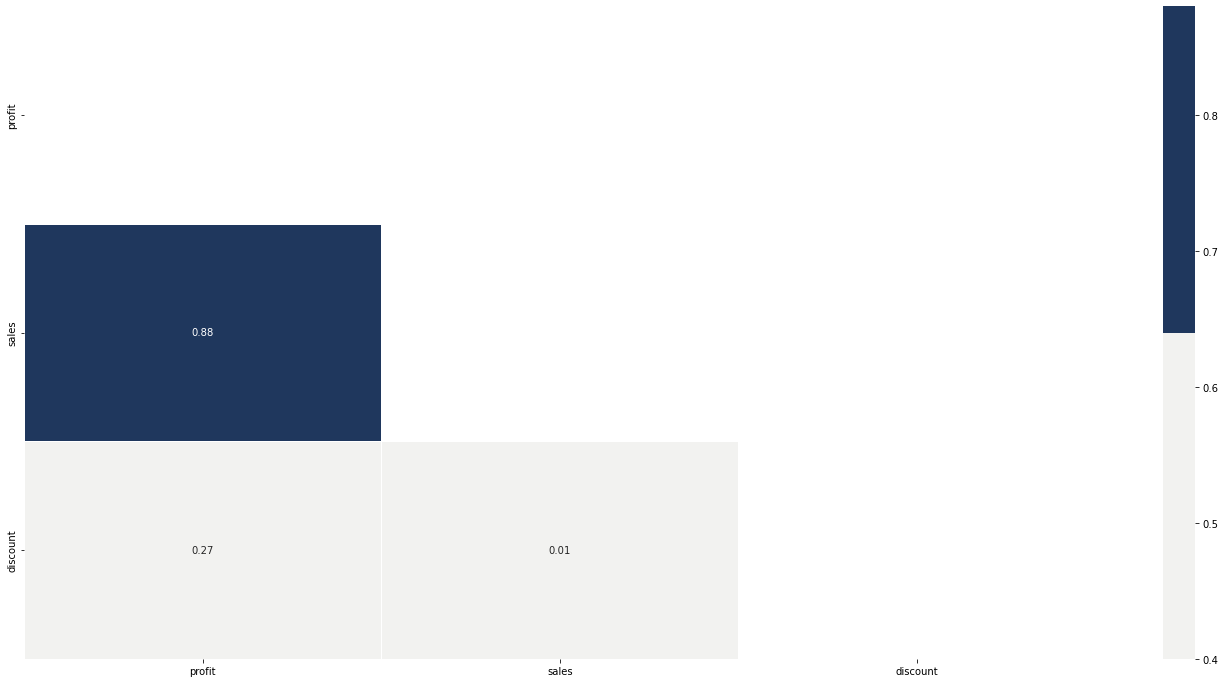

In [80]:
plt.figure(figsize=(24, 12))
correlations = df[features].corr().abs().round(2)
mask = np.triu(np.ones_like(correlations, dtype=bool))
sns.heatmap(correlations, mask=mask, linewidths=1, annot=True, cmap=['#F2F2F0','#1F375D'], vmin=0.40) #vmax=-0.40
plt.show()

## 5.1.4 Modeling

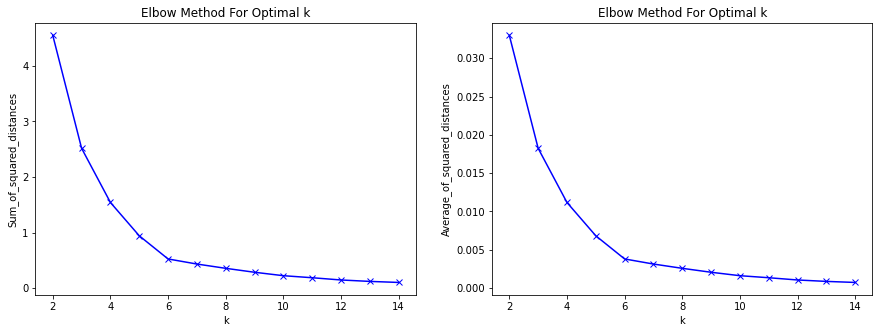

Wall time: 832 ms


In [81]:
%%time
sum_of_squared_distances = []
average_of_squared_distances = []

K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k, max_iter=500, random_state=42)
    km = km.fit(X)
    sum_of_squared_distances.append(km.inertia_) 
    
    distortion = ((X - km.cluster_centers_[km.predict(X)])**2.0).sum(axis=1).mean()
    average_of_squared_distances.append(distortion)
     
plt.figure(figsize=(15, 5))
plt.subplot( 1, 2, 1 )
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.subplot( 1, 2, 2 )
plt.plot(K, average_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Average_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

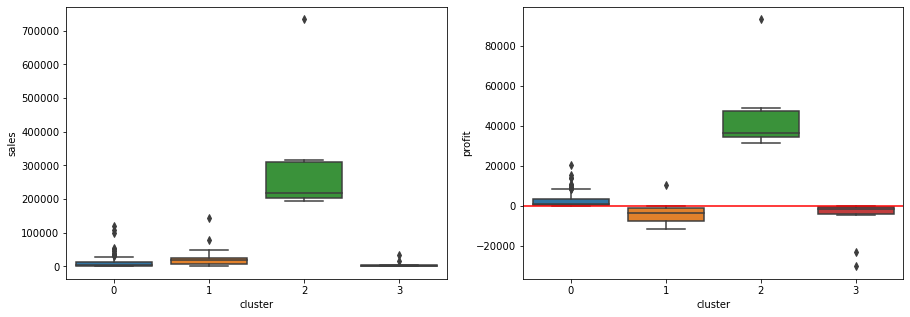

In [82]:
kmeans = KMeans(n_clusters=4, max_iter=500, random_state=42)
labels = kmeans.fit_predict(X)
countries_abt['cluster'] = labels

boxplot( cluster='cluster', y=['sales', 'profit'], data=countries_abt, showfliers=1)
plt.axhline(0, color='r');

**Since group 1 and 3 are similar, We can pt them together**

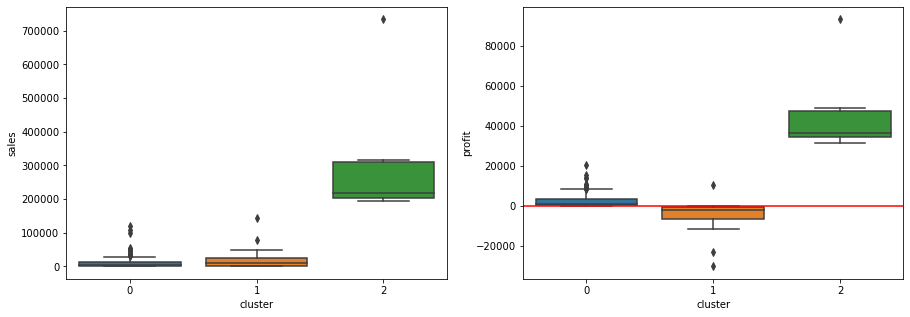

In [83]:
countries_abt['cluster'] = countries_abt['cluster'].apply(lambda x: 1 if x == 3 else x)
boxplot( cluster='cluster', y=['sales', 'profit'], data=countries_abt, showfliers=1)
plt.axhline(0, color='r');

In [84]:
cluster_stats(countries_abt, 'sales', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
0,13201.997036,21520.624403,49.500,1687.70100,4775.8500,13263.865500,28179.670048,35233.21800,119772.11332
1,19539.280219,28971.063648,150.480,1804.77000,10332.8670,23992.959060,29442.243240,39316.15704,145334.78100
2,298393.809652,182555.824952,194005.041,202643.91263,217758.1605,310011.257625,314418.312375,440497.27836,733947.02320


## 5.2 Analysis

Since this countries_abt is a summary of the transactions in the countries. I'll save the clusters and open another notebook for deeper and further analysis.

### 2nd Cycle:

**3 Clusters - Countries with:**

**_0 - Good Performance_**

    
        Profit:
            Mean Profit = $ 2,890
            
        Sales:
            Mean Sales = $ 13,201
            
        Discounts:
            Lowest Discounts (90% of them are below 1%)
            
        Shipping Cost:
            Mean Shippig Cost = $ 1,433
            

**_1 - Bad Performance_**


        Profit:
            Deficit: 90% of profit is lower than $ -176 
            Mean Profit = $ -4,591
            
        Sales:
            Mean Sales = $ 19,539
            
        Discounts:
            Very High Discounts (varying from 20% to 70%)
            
        Shipping Cost:
            Mean Shippig Cost = $ 2,070
            

**_2 - High Performance_**


        Profit:
            Over $ 30,000
            
        Sales:
            Over $ 190,000
            
        Discounts:
            Below 16%
            
        Shipping Cost:
            Over $ 19,000
            

<br>

<br>


### 1st Cycle:

**4 Clusters:**

        0, 1, and 3:
            Similar Sales and Shipping Cost


0

        Most Countries lie here (99)
        Low Positive Profit (up to 20,000 - 90% Quantile= 8,500)
        Lowest Discounts (90% Quantile < 1%)
        75% of countries are above 168 products sold (up to 400 in the 90% quantile)

1

        Negative Profit (90% of profit is lower than -488)
        High Discounts (varying from 20% to 50%)
        75% of countries are over 180 products sold

2

        Very High Sales (Over 190,000)
        Very High Profit (Above 30,000)
        Very High Shipping Cost (Above 19,000)
        Low Discounts (up to 15%)
        Very High Quantity (More than 2,000 products sold)

3

        Full of Negative Profit (max profit is equal to -259)
        Very High Discounts (above %60)
        75% of countries are above 84 products sold

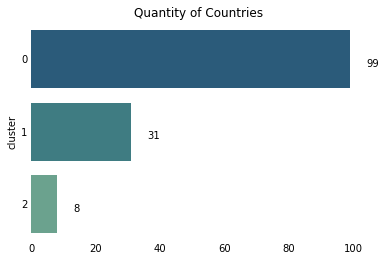

In [85]:
count_plot(countries_abt, cluster_col="cluster", palette='crest_r', title='Quantity of Countries');

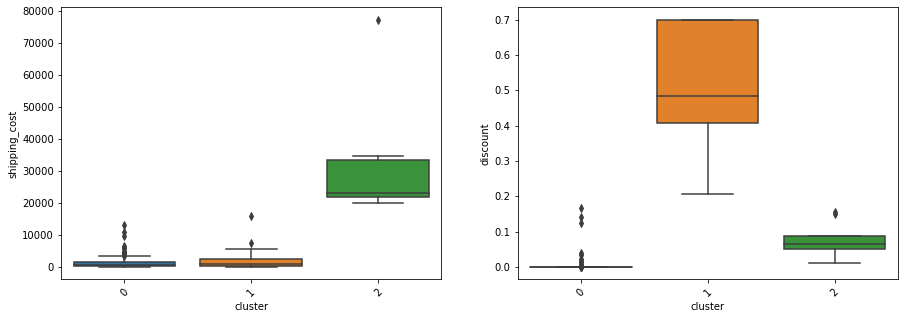

In [86]:
boxplot( cluster='cluster', y=['shipping_cost', 'discount'], data=countries_abt, xticks_rotation=45, showfliers=1)

In [87]:
cluster_stats(countries_abt, 'discount', quantile_1=.85, quantile_2=.9)

,mean,std,min,25%,50%,75%,85%,90%,max
cluster,,,,,,,,,
0,0.005819,0.025430,0.000000,0.000000,0.000000,0.000000,0.000127,0.003214,0.166667
1,0.491426,0.162158,0.207477,0.406989,0.484135,0.700000,0.700000,0.700000,0.700000
2,0.073977,0.052971,0.011278,0.051751,0.063728,0.086448,0.144632,0.151047,0.156317


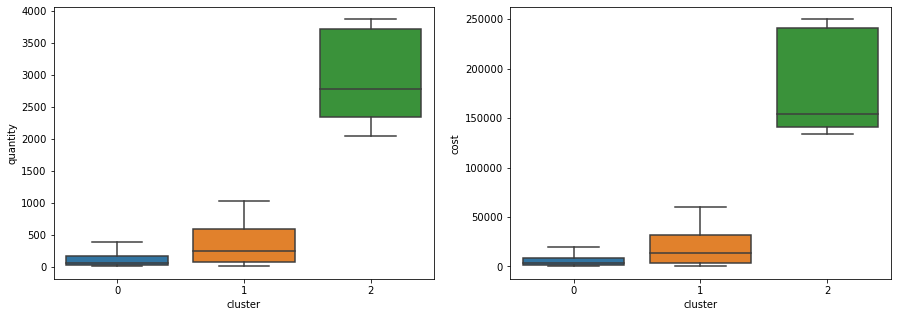

In [88]:
boxplot( cluster='cluster', y=['quantity', 'cost'], data=countries_abt, showfliers=0)

## 5.3 Random Forest

In [89]:
x = countries_abt.drop(columns=['cluster'])[features]
y = countries_abt['cluster']

In [90]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=0)
pd.concat([y_train.value_counts(), y_test.value_counts()], axis=1)

random_forest_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=0)
random_forest_model.fit(X_train, y_train)

y_pred = random_forest_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       1.00      0.91      0.95        11
           2       0.75      1.00      0.86         3

    accuracy                           0.96        56
   macro avg       0.91      0.96      0.93        56
weighted avg       0.97      0.96      0.97        56



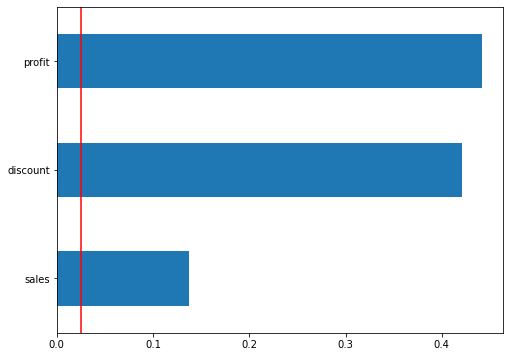

In [92]:
feature_importances = pd.Series(random_forest_model.feature_importances_, index=x.columns).sort_values(ascending=True)
feature_importances.plot.barh(figsize=(8, 6))
plt.axvline(0.025, c='r');

In [93]:
# feature_importances.tail(15).index

Saving Table

In [94]:
countries_abt['cluster'] = countries_abt['cluster'].map({0:'Good Performance', 1:'Bad Performance', 2:'High Performance'})

In [95]:
countries_abt.reset_index()[['country', 'cluster']].to_parquet(join_paths([directory.DATA_DIR, "processed", "country_segmentation", "countries_and_clusters.parquet"]))